# Регрессия IC50



In [1]:
# Установка библиотек для Google Colab
!pip -q install xgboost lightgbm openpyxl seaborn


In [2]:
# Загрузка исходного файла с данными

import os
from google.colab import files

DATA_PATH = '/content/drug_data.xlsx'

if not os.path.exists(DATA_PATH):
    uploaded = files.upload()
    if 'drug_data.xlsx' not in uploaded:

        first_file = next(iter(uploaded.keys()))
        os.rename(first_file, DATA_PATH)

os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)
print(f'Файл данных: {DATA_PATH}')
print('Папки reports/ и models/ готовы')


Файл данных: /content/drug_data.xlsx
Папки reports/ и models/ готовы


## Основной код

РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ IC50
Размер данных: (1001, 210)
Целевая переменная: IC50
Диапазон IC50: [0.004, 4128.529]
Медиана IC50: 46.585
Удаляем 18 константных признаков
Удаляем 32 высококоррелированных признаков
Итоговое количество признаков: 160
Обнаружены пропущенные значения. Производится импутация...
Импутация завершена.
Обучающая выборка: (800, 160)
Тестовая выборка: (201, 160)

Статистика целевой переменной:
Обучающая: mean=204.235, std=341.756
Тестовая: mean=296.718, std=578.988

1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ
----------------------------------------
Определено 11 моделей:
   1. Linear Regression
   2. Ridge Regression
   3. Lasso Regression
   4. ElasticNet
   5. Random Forest
   6. Extra Trees
   7. Gradient Boosting
   8. XGBoost
   9. LightGBM
  10. SVR
  11. Neural Network

2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ
----------------------------------------
Обучение Linear Regression...
  RMSE: 57425.1142 ± 114177.1534
Обучение Ridge Regression...
  RMSE: 453.0556 ± 268.4838
Обучение Lasso Reg

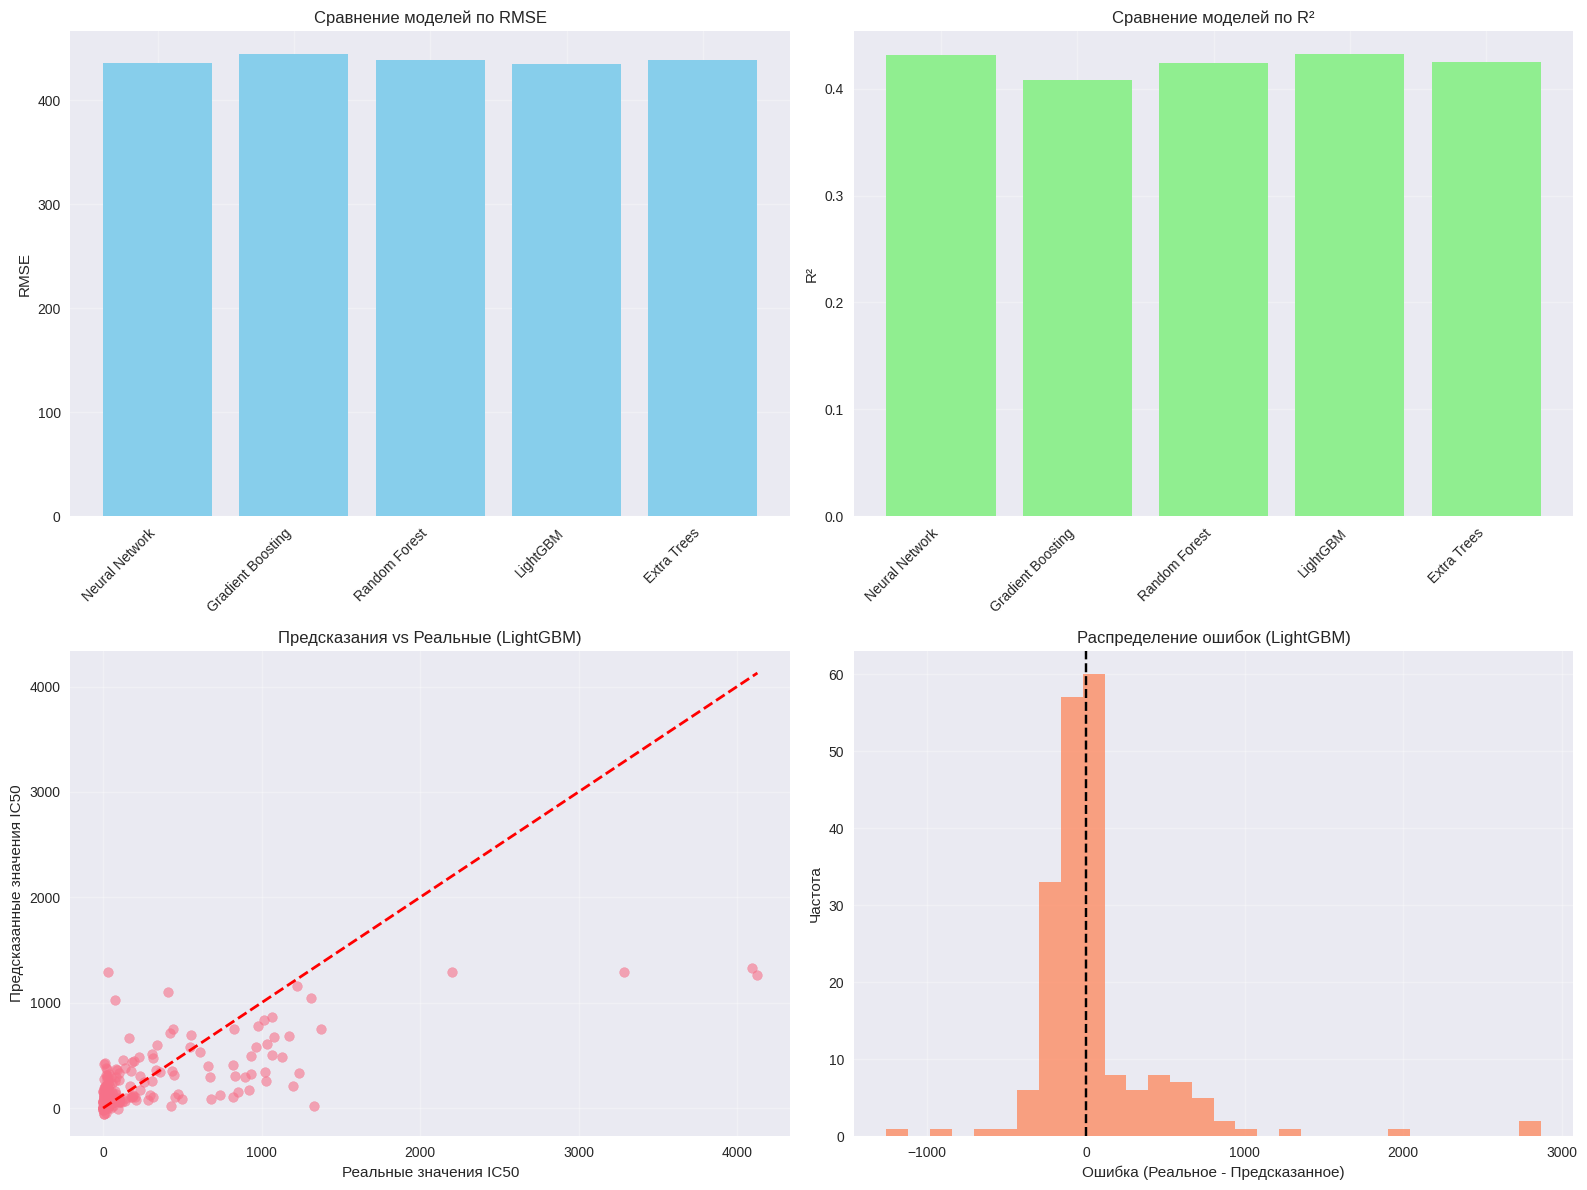

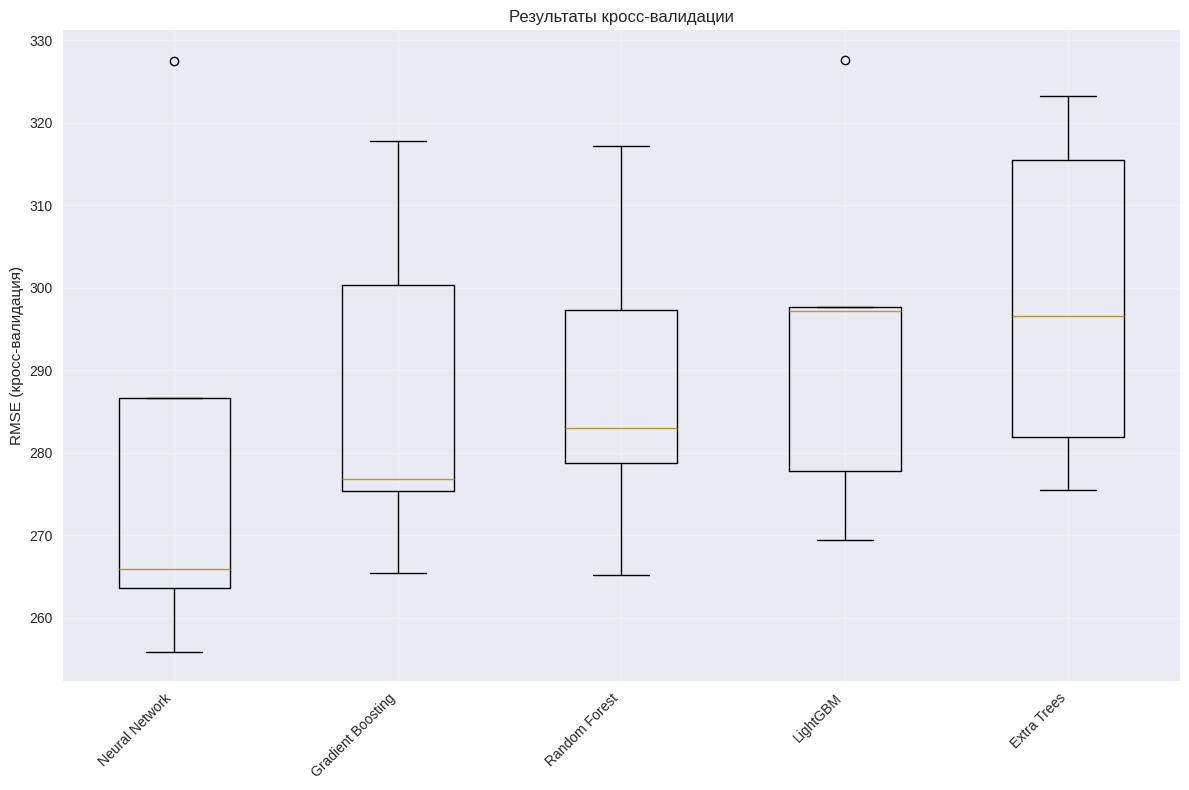


6. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
----------------------------------------
Топ-20 наиболее важных признаков:
  11. FpDensityMorgan3               | 26.0000
  24. Chi2n                          | 26.0000
  21. BalabanJ                       | 22.0000
   4. qed                            | 20.0000
  99. MolLogP                        | 20.0000
  68. EState_VSA4                    | 20.0000
  69. EState_VSA5                    | 19.0000
  15. BCUT2D_CHGLO                   | 17.0000
  72. EState_VSA8                    | 17.0000
  19. BCUT2D_MRLOW                   | 17.0000
   2. MinAbsEStateIndex              | 17.0000
  79. VSA_EState5                    | 16.0000
  67. EState_VSA3                    | 16.0000
  23. Chi1n                          | 16.0000
  27. Ipc                            | 15.0000
   6. MaxPartialCharge               | 14.0000
  40. PEOE_VSA7                      | 14.0000
  78. VSA_EState4                    | 14.0000
  18. BCUT2D_MRHI                    | 14.0000
  

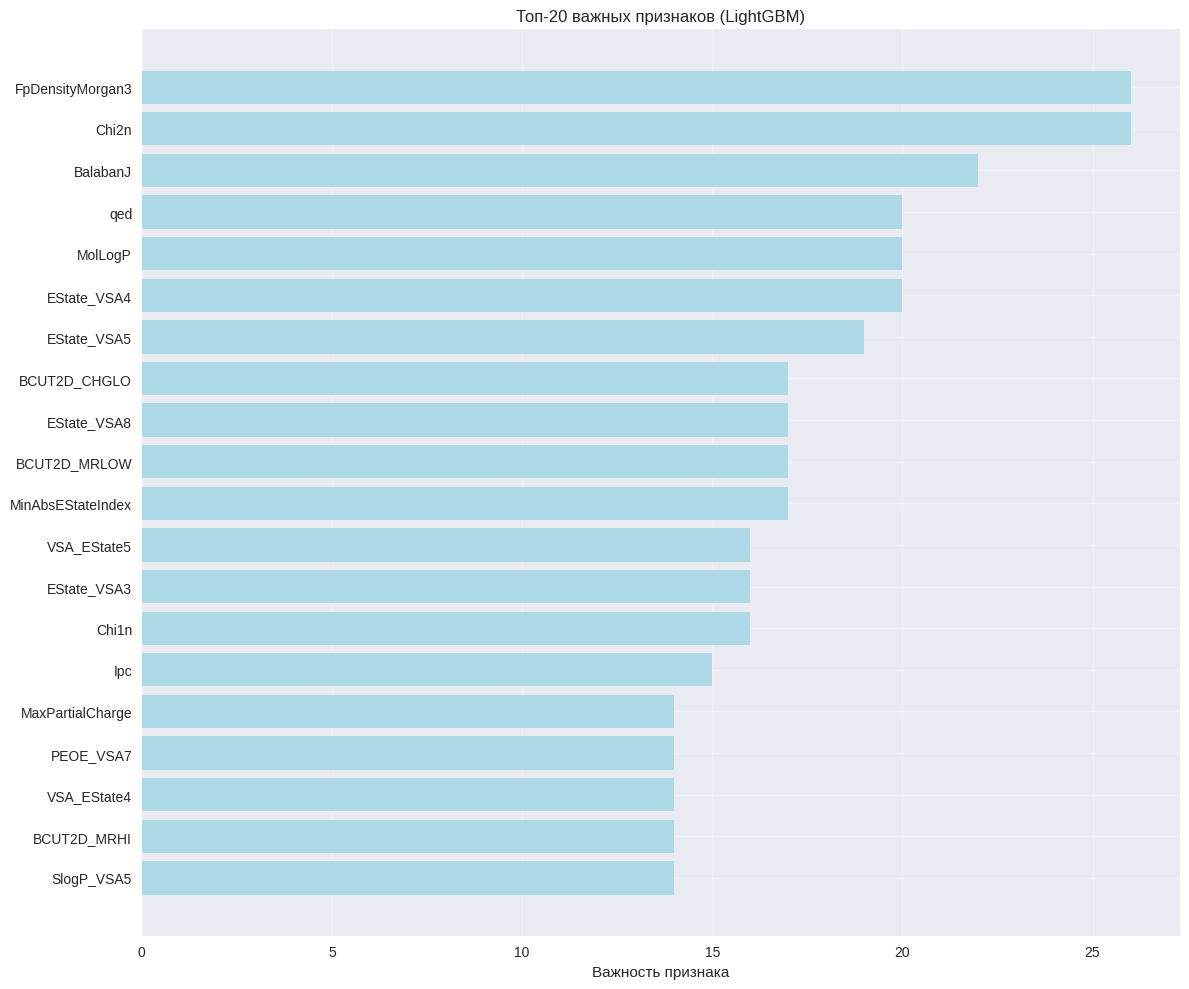


7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
Результаты сохранены:
  • reports/ic50_regression_results.csv - сравнение моделей
  • reports/ic50_feature_importance.csv - важности признаков
  • reports/ic50_predictions.csv - предсказания

МОДЕЛИРОВАНИЕ IC50 ЗАВЕРШЕНО!
Лучшая модель: LightGBM
RMSE: 435.1100
R²: 0.4324


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

class IC50Predictor:
    """Класс для прогнозирования IC50"""

    def __init__(self):
        self.models = {}
        self.results = {}
        self.best_model = None
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean') # Initialize imputer

    def load_and_prepare_data(self):
        """Загрузка и подготовка данных"""
        print("="*60)
        print("РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ IC50")
        print("="*60)

        # Загрузка данных
        df = pd.read_excel(DATA_PATH)

        # Переименование целевых столбцов
        df = df.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})

        # Удаление индексного столбца
        if 'Unnamed: 0' in df.columns:
            df = df.drop('Unnamed: 0', axis=1)

        # Разделение на признаки и целевую переменную
        self.target_col = 'IC50'
        feature_cols = [col for col in df.columns if col not in ['IC50', 'CC50', 'SI']]

        X = df[feature_cols].copy()
        y = df[self.target_col].copy()

        print(f"Размер данных: {X.shape}")
        print(f"Целевая переменная: {self.target_col}")
        print(f"Диапазон {self.target_col}: [{y.min():.3f}, {y.max():.3f}]")
        print(f"Медиана {self.target_col}: {y.median():.3f}")

        # Проверка и удаление константных признаков
        constant_features = X.columns[X.nunique() <= 1]
        if len(constant_features) > 0:
            print(f"Удаляем {len(constant_features)} константных признаков")
            X = X.drop(constant_features, axis=1)

        # Удаление высококоррелированных признаков
        corr_matrix = X.corr().abs()
        upper_triangle = np.triu(np.ones_like(corr_matrix), k=1)
        high_corr_pairs = np.where((corr_matrix > 0.95) & upper_triangle)

        features_to_remove = set()
        for i in range(len(high_corr_pairs[0])):
            idx1, idx2 = high_corr_pairs[0][i], high_corr_pairs[1][i]
            feature1, feature2 = X.columns[idx1], X.columns[idx2]
            # Удаляем признак с меньшей корреляцией с целевой переменной
            corr1 = abs(np.corrcoef(X[feature1], y)[0,1])
            corr2 = abs(np.corrcoef(X[feature2], y)[0,1])
            if corr1 < corr2:
                features_to_remove.add(feature1)
            else:
                features_to_remove.add(feature2)

        if features_to_remove:
            print(f"Удаляем {len(features_to_remove)} высококоррелированных признаков")
            X = X.drop(list(features_to_remove), axis=1)

        print(f"Итоговое количество признаков: {X.shape[1]}")

        # Impute missing values after feature selection
        if X.isnull().sum().sum() > 0:
            print("Обнаружены пропущенные значения.")
            X = pd.DataFrame(self.imputer.fit_transform(X), columns=X.columns, index=X.index)
            print("Импутация завершена.")

        # Разделение на обучающую и тестовую выборки
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=None
        )

        print(f"Обучающая выборка: {self.X_train.shape}")
        print(f"Тестовая выборка: {self.X_test.shape}")

        # Проверяем распределение целевой переменной
        print(f"\nСтатистика целевой переменной:")
        print(f"Обучающая: mean={self.y_train.mean():.3f}, std={self.y_train.std():.3f}")
        print(f"Тестовая: mean={self.y_test.mean():.3f}, std={self.y_test.std():.3f}")

        return X, y

    def define_models(self):
        """Определение моделей для тестирования"""
        print(f"\n1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ")
        print("-"*40)

        self.models = {
            'Linear Regression': Pipeline([
                ('scaler', StandardScaler()),
                ('model', LinearRegression())
            ]),

            'Ridge Regression': Pipeline([
                ('scaler', StandardScaler()),
                ('model', Ridge(random_state=42))
            ]),

            'Lasso Regression': Pipeline([
                ('scaler', StandardScaler()),
                ('model', Lasso(random_state=42, max_iter=2000))
            ]),

            'ElasticNet': Pipeline([
                ('scaler', StandardScaler()),
                ('model', ElasticNet(random_state=42, max_iter=2000))
            ]),

            'Random Forest': RandomForestRegressor(
                n_estimators=100, random_state=42, n_jobs=-1
            ),

            'Extra Trees': ExtraTreesRegressor(
                n_estimators=100, random_state=42, n_jobs=-1
            ),

            'Gradient Boosting': GradientBoostingRegressor(
                random_state=42
            ),

            'XGBoost': xgb.XGBRegressor(
                random_state=42, n_jobs=-1, verbosity=0
            ),

            'LightGBM': lgb.LGBMRegressor(
                random_state=42, n_jobs=-1, verbosity=-1
            ),

            'SVR': Pipeline([
                ('scaler', StandardScaler()),
                ('model', SVR(kernel='rbf'))
            ]),

            'Neural Network': Pipeline([
                ('scaler', StandardScaler()),
                ('model', MLPRegressor(random_state=42, max_iter=500))
            ])
        }

        print(f"Определено {len(self.models)} моделей:")
        for i, name in enumerate(self.models.keys(), 1):
            print(f"  {i:2d}. {name}")

    def evaluate_models(self):
        """Оценка всех моделей с кросс-валидацией"""
        print(f"\n2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ")
        print("-"*40)

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        for name, model in self.models.items():
            print(f"Обучение {name}...")

            # Кросс-валидация
            cv_scores = cross_val_score(
                model, self.X_train, self.y_train,
                cv=cv, scoring='neg_mean_squared_error', n_jobs=-1
            )

            rmse_scores = np.sqrt(-cv_scores)

            self.results[name] = {
                'cv_rmse_mean': rmse_scores.mean(),
                'cv_rmse_std': rmse_scores.std(),
                'cv_scores': rmse_scores
            }

            print(f"  RMSE: {rmse_scores.mean():.4f} \u00B1 {rmse_scores.std():.4f}")

        # Сортировка результатов
        sorted_models = sorted(
            self.results.items(),
            key=lambda x: x[1]['cv_rmse_mean']
        )

        print(f"\nРАНГИ МОДЕЛЕЙ (по RMSE на кросс-валидации):")
        print("-"*50)
        for i, (name, metrics) in enumerate(sorted_models, 1):
            print(f"{i:2d}. {name:<20} | RMSE: {metrics['cv_rmse_mean']:.4f} \u00B1 {metrics['cv_rmse_std']:.4f}")

        return sorted_models

    def hyperparameter_tuning(self, top_models=3):
        """Настройка гиперпараметров для лучших моделей"""
        print(f"\n3. НАСТРОЙКА ГИПЕРПАРАМЕТРОВ")
        print("-"*40)

        # Получаем топ модели
        sorted_models = sorted(
            self.results.items(),
            key=lambda x: x[1]['cv_rmse_mean']
        )

        param_grids = {
            'Random Forest': {
                'n_estimators': [50, 100, 200],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5, 10]
            },

            'XGBoost': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 6, 10],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 1.0]
            },

            'LightGBM': {
                'n_estimators': [50, 100, 200],
                'max_depth': [3, 6, 10],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 1.0]
            },

            'Ridge Regression': {
                'model__alpha': [0.1, 1.0, 10.0, 100.0]
            },

            'Lasso Regression': {
                'model__alpha': [0.001, 0.01, 0.1, 1.0]
            },

            'SVR': {
                'model__C': [0.1, 1, 10],
                'model__gamma': ['scale', 'auto', 0.01, 0.1]
            }
        }

        tuned_models = {}

        for name, _ in sorted_models[:top_models]:
            if name in param_grids:
                print(f"Настройка {name}...")

                grid_search = GridSearchCV(
                    self.models[name],
                    param_grids[name],
                    cv=3,
                    scoring='neg_mean_squared_error',
                    n_jobs=-1,
                    verbose=0
                )

                grid_search.fit(self.X_train, self.y_train)

                tuned_models[name] = {
                    'model': grid_search.best_estimator_,
                    'best_params': grid_search.best_params_,
                    'best_score': -grid_search.best_score_
                }

                print(f"  Лучший RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
                print(f"  Лучшие параметры: {grid_search.best_params_}")
            else:
                # Используем базовую модель
                model = self.models[name]
                model.fit(self.X_train, self.y_train)

                pred_train = model.predict(self.X_train)
                score = mean_squared_error(self.y_train, pred_train)

                tuned_models[name] = {
                    'model': model,
                    'best_params': {},
                    'best_score': score
                }

        return tuned_models

    def final_evaluation(self, tuned_models):
        """Финальная оценка на тестовой выборке"""
        print(f"\n4. ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
        print("-"*40)

        final_results = {}

        for name, model_info in tuned_models.items():
            model = model_info['model']

            # Предсказания на тестовой выборке
            y_pred = model.predict(self.X_test)

            # Метрики
            rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
            mae = mean_absolute_error(self.y_test, y_pred)
            r2 = r2_score(self.y_test, y_pred)

            final_results[name] = {
                'model': model,
                'y_pred': y_pred,
                'rmse': rmse,
                'mae': mae,
                'r2': r2
            }

            print(f"{name}:")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE:  {mae:.4f}")
            print(f"  R\u00B2:   {r2:.4f}")
            print()

        # Определяем лучшую модель
        best_model_name = min(final_results.keys(),
                             key=lambda x: final_results[x]['rmse'])
        self.best_model = final_results[best_model_name]['model']

        print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
        print(f"RMSE: {final_results[best_model_name]['rmse']:.4f}")
        print(f"R\u00B2: {final_results[best_model_name]['r2']:.4f}")

        return final_results, best_model_name

    def create_visualizations(self, final_results, best_model_name):
        """Создание визуализаций результатов"""
        print(f"\n5. СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
        print("-"*40)

        # График сравнения моделей
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Сравнение RMSE
        model_names = list(final_results.keys())
        rmse_values = [final_results[name]['rmse'] for name in model_names]

        axes[0, 0].bar(range(len(model_names)), rmse_values, color='skyblue')
        axes[0, 0].set_xticks(range(len(model_names)))
        axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 0].set_ylabel('RMSE')
        axes[0, 0].set_title('Сравнение моделей по RMSE')
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Сравнение R\u00B2
        r2_values = [final_results[name]['r2'] for name in model_names]

        axes[0, 1].bar(range(len(model_names)), r2_values, color='lightgreen')
        axes[0, 1].set_xticks(range(len(model_names)))
        axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 1].set_ylabel('R\u00B2')
        axes[0, 1].set_title('Сравнение моделей по R\u00B2')
        axes[0, 1].grid(True, alpha=0.3)

        # 3. Предсказания vs реальные значения (лучшая модель)
        best_results = final_results[best_model_name]
        y_pred = best_results['y_pred']

        axes[1, 0].scatter(self.y_test, y_pred, alpha=0.6)
        axes[1, 0].plot([self.y_test.min(), self.y_test.max()],
                       [self.y_test.min(), self.y_test.max()], 'r--', lw=2)
        axes[1, 0].set_xlabel('Реальные значения IC50')
        axes[1, 0].set_ylabel('Предсказанные значения IC50')
        axes[1, 0].set_title(f'Предсказания vs Реальные ({best_model_name})')
        axes[1, 0].grid(True, alpha=0.3)

        # 4. Распределение ошибок (лучшая модель)
        errors = self.y_test - y_pred

        axes[1, 1].hist(errors, bins=30, alpha=0.7, color='coral')
        axes[1, 1].axvline(0, color='black', linestyle='--')
        axes[1, 1].set_xlabel('Ошибка (Реальное - Предсказанное)')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 1].set_title(f'Распределение ошибок ({best_model_name})')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('reports/ic50_regression_results.png', dpi=300, bbox_inches='tight')
        plt.show()

        # График кросс-валидации
        plt.figure(figsize=(12, 8))
        cv_data = []
        cv_labels = []

        for name in final_results.keys():
            if name in self.results:
                cv_data.append(self.results[name]['cv_scores'])
                cv_labels.append(name)

        plt.boxplot(cv_data, labels=cv_labels)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('RMSE (кросс-валидация)')
        plt.title('Результаты кросс-валидации')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('reports/ic50_crossvalidation.png', dpi=300, bbox_inches='tight')
        plt.show()

    def feature_importance_analysis(self, final_results, best_model_name):
        """Анализ важности признаков"""
        print(f"\n6. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
        print("-"*40)

        best_model = final_results[best_model_name]['model']

        # Получаем важности признаков
        if hasattr(best_model, 'feature_importances_'):
            # Для tree-based моделей
            importances = best_model.feature_importances_
            feature_names = self.X_train.columns
        elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps['model'], 'coef_'):
            # Для линейных моделей в пайплайне
            importances = np.abs(best_model.named_steps['model'].coef_)
            feature_names = self.X_train.columns
        else:
            print("Важности признаков недоступны для данной модели")
            return

        # Создаем DataFrame с важностями
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)

        # Топ-20 признаков
        top_features = importance_df.head(20)

        print("Топ-20 наиболее важных признаков:")
        for i, row in top_features.iterrows():
            print(f"  {row.name+1:2d}. {row['feature'][:30]:<30} | {row['importance']:.4f}")

        # Визуализация важности признаков
        plt.figure(figsize=(12, 10))
        plt.barh(range(len(top_features)), top_features['importance'].values, color='lightblue')
        plt.yticks(range(len(top_features)), top_features['feature'].values)
        plt.xlabel('Важность признака')
        plt.title(f'Топ-20 важных признаков ({best_model_name})')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('reports/ic50_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()

        return importance_df

    def save_model_and_results(self, final_results, best_model_name, importance_df):
        """Сохранение модели и результатов"""
        print(f"\n7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
        print("-"*40)

        # Сохраняем результаты в CSV
        results_summary = []
        for name, metrics in final_results.items():
            results_summary.append({
                'Model': name,
                'RMSE': metrics['rmse'],
                'MAE': metrics['mae'],
                'R2': metrics['r2']
            })

        results_df = pd.DataFrame(results_summary)
        results_df.to_csv('reports/ic50_regression_results.csv', index=False)

        # Сохраняем важности признаков
        importance_df.to_csv('reports/ic50_feature_importance.csv', index=False)

        # Сохраняем предсказания лучшей модели
        predictions_df = pd.DataFrame({
            'True_IC50': self.y_test.values,
            'Predicted_IC50': final_results[best_model_name]['y_pred'],
            'Error': self.y_test.values - final_results[best_model_name]['y_pred']
        })
        predictions_df.to_csv('reports/ic50_predictions.csv', index=False)

        print("Результаты сохранены:")
        print("  \u2022 reports/ic50_regression_results.csv - сравнение моделей")
        print("  \u2022 reports/ic50_feature_importance.csv - важности признаков")
        print("  \u2022 reports/ic50_predictions.csv - предсказания")

        return results_df

def main():
    """Основная функция для обучения моделей регрессии IC50"""

    # Создаем предиктор
    predictor = IC50Predictor()

    # Загружаем и подготавливаем данные
    X, y = predictor.load_and_prepare_data()

    # Определяем модели
    predictor.define_models()

    # Оцениваем модели
    sorted_models = predictor.evaluate_models()

    # Настраиваем гиперпараметры
    tuned_models = predictor.hyperparameter_tuning(top_models=5)

    # Финальная оценка
    final_results, best_model_name = predictor.final_evaluation(tuned_models)

    # Создаем визуализации
    predictor.create_visualizations(final_results, best_model_name)

    # Анализ важности признаков
    importance_df = predictor.feature_importance_analysis(final_results, best_model_name)

    # Сохраняем результаты
    results_df = predictor.save_model_and_results(final_results, best_model_name, importance_df)

    print(f"\nМОДЕЛИРОВАНИЕ IC50 ЗАВЕРШЕНО!")
    print("="*60)
    print(f"Лучшая модель: {best_model_name}")
    print(f"RMSE: {final_results[best_model_name]['rmse']:.4f}")
    print(f"R\u00B2: {final_results[best_model_name]['r2']:.4f}")

if __name__ == "__main__":
    main()
